In [109]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules
from statsmodels.tsa.arima.model import ARIMA
import itertools
from numpy.polynomial.polynomial import polyfit

In [2]:
%pip install openpyxl
%pip install mlxtend
%pip install statsmodels


Note: you may need to restart the kernel to use updated packages.


DEPRECATION: Loading egg at c:\users\rayantech\programs\python\python312\lib\site-packages\argparse-1.4.0-py3.12.egg is deprecated. pip 25.1 will enforce this behaviour change. A possible replacement is to use pip for package installation. Discussion can be found at https://github.com/pypa/pip/issues/12330
DEPRECATION: Loading egg at c:\users\rayantech\programs\python\python312\lib\site-packages\astor-0.8.1-py3.12.egg is deprecated. pip 25.1 will enforce this behaviour change. A possible replacement is to use pip for package installation. Discussion can be found at https://github.com/pypa/pip/issues/12330
DEPRECATION: Loading egg at c:\users\rayantech\programs\python\python312\lib\site-packages\pyggi-2.0-py3.12.egg is deprecated. pip 25.1 will enforce this behaviour change. A possible replacement is to use pip for package installation. Discussion can be found at https://github.com/pypa/pip/issues/12330

[notice] A new release of pip is available: 25.0.1 -> 25.3
[notice] To update, run:

Note: you may need to restart the kernel to use updated packages.


DEPRECATION: Loading egg at c:\users\rayantech\programs\python\python312\lib\site-packages\argparse-1.4.0-py3.12.egg is deprecated. pip 25.1 will enforce this behaviour change. A possible replacement is to use pip for package installation. Discussion can be found at https://github.com/pypa/pip/issues/12330
DEPRECATION: Loading egg at c:\users\rayantech\programs\python\python312\lib\site-packages\astor-0.8.1-py3.12.egg is deprecated. pip 25.1 will enforce this behaviour change. A possible replacement is to use pip for package installation. Discussion can be found at https://github.com/pypa/pip/issues/12330
DEPRECATION: Loading egg at c:\users\rayantech\programs\python\python312\lib\site-packages\pyggi-2.0-py3.12.egg is deprecated. pip 25.1 will enforce this behaviour change. A possible replacement is to use pip for package installation. Discussion can be found at https://github.com/pypa/pip/issues/12330

[notice] A new release of pip is available: 25.0.1 -> 25.3
[notice] To update, run:

Note: you may need to restart the kernel to use updated packages.


DEPRECATION: Loading egg at c:\users\rayantech\programs\python\python312\lib\site-packages\argparse-1.4.0-py3.12.egg is deprecated. pip 25.1 will enforce this behaviour change. A possible replacement is to use pip for package installation. Discussion can be found at https://github.com/pypa/pip/issues/12330
DEPRECATION: Loading egg at c:\users\rayantech\programs\python\python312\lib\site-packages\astor-0.8.1-py3.12.egg is deprecated. pip 25.1 will enforce this behaviour change. A possible replacement is to use pip for package installation. Discussion can be found at https://github.com/pypa/pip/issues/12330
DEPRECATION: Loading egg at c:\users\rayantech\programs\python\python312\lib\site-packages\pyggi-2.0-py3.12.egg is deprecated. pip 25.1 will enforce this behaviour change. A possible replacement is to use pip for package installation. Discussion can be found at https://github.com/pypa/pip/issues/12330

[notice] A new release of pip is available: 25.0.1 -> 25.3
[notice] To update, run:

In [23]:
df = pd.read_excel("Online Retail.xlsx")
print(df.head)
print(df.shape)
print(df.info())

<bound method NDFrame.head of        InvoiceNo StockCode                          Description  Quantity  \
0         536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1         536365     71053                  WHITE METAL LANTERN         6   
2         536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3         536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4         536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   
...          ...       ...                                  ...       ...   
541904    581587     22613          PACK OF 20 SPACEBOY NAPKINS        12   
541905    581587     22899         CHILDREN'S APRON DOLLY GIRL          6   
541906    581587     23254        CHILDRENS CUTLERY DOLLY GIRL          4   
541907    581587     23255      CHILDRENS CUTLERY CIRCUS PARADE         4   
541908    581587     22138        BAKING SET 9 PIECE RETROSPOT          3   

               InvoiceDate  UnitPrice  Custom

Handle Missing Values

In [24]:
print("Before removing missing values:\n", df.isna().sum())

Before removing missing values:
 InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64


In [25]:
df = df[df["Description"].notna() & (df["Description"] != "")]
# Define non-product stock codes to exclude
non_product_stockcodes = [
    "POST", # Postage
    "DOT", # DOTCOM POSTAGE
    "D", # Discount
    "M", # Manual
    "m", # Manual (lowercase)
    "C2", # Carriage
    "AMAZONFEE", # Amazon marketplace fee
    "BANK CHARGES", # Bank charges
    "CRUK", # Charity commission (Cancer Research UK)
    "S", # Samples
    "B", # Bad debt adjustment
    "PADS", # Pads (service item)
]

# Convert StockCode to string for comparison
df["StockCode"] = df["StockCode"].astype(str).str.strip().str.upper()

# Count and remove non-product stock codes
rows_before_stockcode = len(df)
non_product_mask = df["StockCode"].isin(
    [code.upper() for code in non_product_stockcodes]
)
non_product_counts = df[non_product_mask]["StockCode"].value_counts()
if len(non_product_counts) > 0:
    print("Non-product stock codes found:")
    for code, count in non_product_counts.items():
        print(f" - {code}: {count} records")

df = df[~non_product_mask]
print(f"Removed {rows_before_stockcode - len(df)} non-product stock code records")

# --- 3. Description Standardization (Convert to lowercase) ---
print("\n--- 3. Description Standardization ---")
df["Description"] = df["Description"].astype(str).str.strip().str.lower()
print("All descriptions converted to lowercase and whitespace stripped")

# Define patterns for anomalous descriptions (bad debt, adjustments, damages, etc.)
anomaly_description_patterns = [
    "adjust", # Adjustments
    "bad debt", # Bad debt write-offs
    "damages", # Damaged goods
    "lost", # Lost inventory
    "incorrect",
    "thrown away", # Discarded items
    "crushed", # Damaged in transit
    "wet", # Water damage
    "rusty", # Rust damage
    "mouldy", # Mold damage
    "smashed", # Broken items
    "broken", # Broken items
    "amazon fee", # Amazon fees
    "bank charges", # Bank fees
    "carriage", # Carriage/delivery charges
    "dotcom", # Dotcom adjustments
    "given away", # Free items
    "mailout", # Mailing costs
    "manual", # Manual adjustments
    "cruk", # Charity commission
    "samples", # Sample items
    "?", # Unknown/unclear items (question marks)
    "allocate stock", # Stock allocation entries
    "check", # Check/verification entries
    "incorrect", # Incorrect entries
    "wrong", # Wrong entries
    "test", # Test entries
    "mixed up", # Mixed up items
    "sold as set", # Adjustment for set items
    "counted", # Counting adjustments
    "show sample", # Show samples
    "had been put aside", # Put aside items
    "amazon adjust", # Amazon adjustments
    "found", # Found items (inventory adjustments)
]

rows_before_desc_patterns = len(df)
anomaly_desc_mask = pd.Series([False] * len(df), index=df.index)

print("Anomalous description patterns found:")
for pattern in anomaly_description_patterns:
    pattern_mask = df["Description"].str.contains(pattern, na=False, regex=False)
    pattern_count = pattern_mask.sum()
    if pattern_count > 0:
        print(f" - '{pattern}': {pattern_count} records")
        anomaly_desc_mask = anomaly_desc_mask | pattern_mask

df = df[~anomaly_desc_mask]
print(
    f"Removed {rows_before_desc_patterns - len(df)} records with anomalous descriptions"
)
print("After removing missing values:\n", df.isna().sum())
print("After removing missing values:\n", df.isna().sum())

Non-product stock codes found:
 - POST: 1252 records
 - DOT: 709 records
 - M: 572 records
 - C2: 143 records
 - D: 77 records
 - S: 63 records
 - BANK CHARGES: 37 records
 - AMAZONFEE: 34 records
 - CRUK: 16 records
 - PADS: 4 records
 - B: 3 records
Removed 2910 non-product stock code records

--- 3. Description Standardization ---
All descriptions converted to lowercase and whitespace stripped
Anomalous description patterns found:
 - 'adjust': 31 records
 - 'damages': 61 records
 - 'lost': 6 records
 - 'incorrect': 7 records
 - 'thrown away': 20 records
 - 'crushed': 5 records
 - 'wet': 17 records
 - 'rusty': 8 records
 - 'mouldy': 4 records
 - 'smashed': 4 records
 - 'broken': 1 records
 - 'carriage': 178 records
 - 'dotcom': 83 records
 - 'given away': 1 records
 - 'mailout': 4 records
 - 'samples': 4 records
 - '?': 82 records
 - 'allocate stock': 1 records
 - 'check': 418 records
 - 'incorrect': 7 records
 - 'wrong': 19 records
 - 'test': 3 records
 - 'mixed up': 2 records
 - 's

Remove invalid records

In [26]:
bad_cnt = df[(df["Quantity"] <= 0)].shape[0]
print("Rows with zero or negative quantity BEFORE:", bad_cnt)

df_clean = df[df["Quantity"] > 0]
after_cnt = df_clean[(df_clean["Quantity"] <= 0)].shape[0]
print("Rows with zero or negative quantity AFTER:", after_cnt)
df = df_clean

Rows with zero or negative quantity BEFORE: 8796
Rows with zero or negative quantity AFTER: 0


In [27]:
bad_cnt = df[(df["UnitPrice"] <= 0)].shape[0]
print("Rows with zero or negative UnitPrice BEFORE:", bad_cnt)

df_clean = df[df["UnitPrice"] > 0]
after_cnt = df_clean[(df_clean["UnitPrice"] <= 0)].shape[0]
print("Rows with zero or negative quantity AFTER:", after_cnt)
df = df_clean

Rows with zero or negative UnitPrice BEFORE: 448
Rows with zero or negative quantity AFTER: 0


Data type conversion

In [28]:
print("BEFORE: ", df["InvoiceDate"].dtype)
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])
print("AFTER: ", df["InvoiceDate"].dtype)

BEFORE:  datetime64[ns]
AFTER:  datetime64[ns]


Feature engineering

In [29]:
df["TotalAmount"] = df["Quantity"] * df["UnitPrice"]
print(df.columns ,df["Quantity"].head, df["UnitPrice"].head, df["TotalAmount"].head)

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country', 'TotalAmount'],
      dtype='object') <bound method NDFrame.head of 0          6
1          6
2          8
3          6
4          6
          ..
541904    12
541905     6
541906     4
541907     4
541908     3
Name: Quantity, Length: 527326, dtype: int64> <bound method NDFrame.head of 0         2.55
1         3.39
2         2.75
3         3.39
4         3.39
          ... 
541904    0.85
541905    2.10
541906    4.15
541907    4.15
541908    4.95
Name: UnitPrice, Length: 527326, dtype: float64> <bound method NDFrame.head of 0         15.30
1         20.34
2         22.00
3         20.34
4         20.34
          ...  
541904    10.20
541905    12.60
541906    16.60
541907    16.60
541908    14.85
Name: TotalAmount, Length: 527326, dtype: float64>


In [30]:
df = df[~df["InvoiceNo"].astype(str).str.startswith("C")]
print(df.columns)

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country', 'TotalAmount'],
      dtype='object')


In [31]:
original_count = df.shape[0]
# df_grouped = df.groupby(["InvoiceNo", "Description"], as_index=False)["Quantity"].sum()
df["Quantity_sum"] = df.groupby(["InvoiceNo", "Description"])["Quantity"].transform("sum")
df_grouped = df.drop_duplicates(subset=["InvoiceNo", "Description"])

new_count = df_grouped.shape[0]
print("Before:", original_count)
print("After:", new_count)

print(df_grouped.columns, df.columns)

Before: 527326
After: 516565
Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country', 'TotalAmount', 'Quantity_sum'],
      dtype='object') Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country', 'TotalAmount', 'Quantity_sum'],
      dtype='object')


In [32]:
product_counts = df_grouped["Description"].value_counts()
frequent_products = product_counts[product_counts >= 10].index
df_filtered = df_grouped[df_grouped["Description"].isin(frequent_products)]
print(df_filtered["Description"].value_counts().min())

df_grouped = df_filtered

10


Preprocessing for Association Rule Mining

In [33]:
baskets = df_grouped.groupby("InvoiceNo")["Description"].apply(list).reset_index()
print(baskets.head)

<bound method NDFrame.head of        InvoiceNo                                        Description
0         536365  [white hanging heart t-light holder, white met...
1         536366  [hand warmer union jack, hand warmer red polka...
2         536367  [assorted colour bird ornament, poppy's playho...
3         536368  [jam making set with jars, red coat rack paris...
4         536369                         [bath building block word]
...          ...                                                ...
19731     581583  [lunch bag red retrospot, 6 chocolate love hea...
19732     581584  [red flock love heart photo frame, 6 chocolate...
19733     581585  [black tea towel classic design, assorted bott...
19734     581586  [large cake stand  hanging strawbery, set of 3...
19735     581587  [circus parade lunch box, plasters in tin circ...

[19736 rows x 2 columns]>


Preprocessing for Time Series Analysis

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country', 'TotalAmount', 'Quantity_sum'],
      dtype='object')


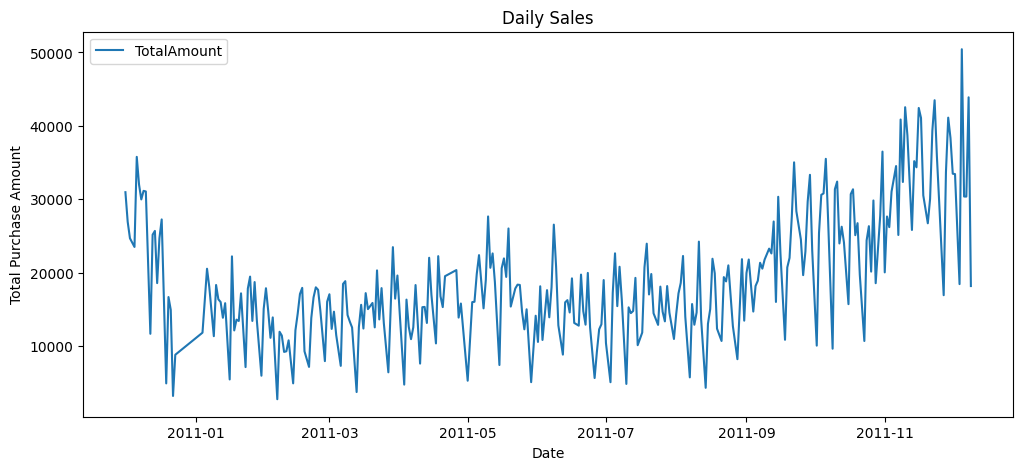

In [106]:
print(df.columns)

df["InvoiceDay"] = df["InvoiceDate"].dt.date
daily_sales = df.groupby("InvoiceDay")["TotalAmount"].sum().reset_index()
daily_sales.columns = ["Date", "TotalAmount"]
daily_sales = daily_sales.sort_values("Date")

daily_sales.plot(x="Date", y="TotalAmount", kind="line", figsize=(12,5))
plt.ylabel("Total Purchase Amount")
plt.title("Daily Sales")
plt.show()

Exploratory Data Analysis (EDA)

General Dataset Exploration 

            Quantity                    InvoiceDate      UnitPrice  \
count  527326.000000                         527326  527326.000000   
mean       10.574472  2011-07-04 21:46:56.296180992       3.261314   
min         1.000000            2010-12-01 08:26:00       0.040000   
25%         1.000000            2011-03-28 12:23:00       1.250000   
50%         3.000000            2011-07-20 13:30:00       2.080000   
75%        11.000000            2011-10-19 13:58:00       4.130000   
max     80995.000000            2011-12-09 12:50:00     649.500000   
std       155.898030                            NaN       4.374171   

          CustomerID    TotalAmount   Quantity_sum  
count  396042.000000  527326.000000  527326.000000  
mean    15301.627916      19.466690      10.742266  
min     12346.000000       0.060000       1.000000  
25%     13975.000000       3.750000       1.000000  
50%     15159.000000       9.900000       4.000000  
75%     16803.000000      17.400000      12.000000 

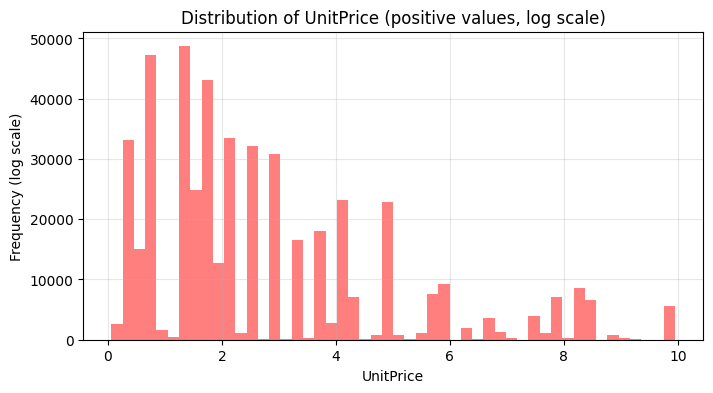

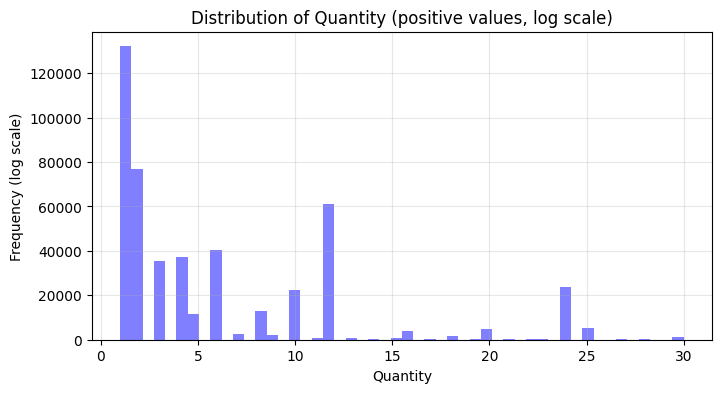

Description
white hanging heart t-light holder    1972
jumbo bag red retrospot               1870
lunch bag red retrospot               1503
party bunting                         1347
lunch bag  black skull.               1289
pack of 72 retrospot cake cases       1244
assorted colour bird ornament         1238
natural slate heart chalkboard        1226
lunch bag spaceboy design             1152
set of 3 cake tins pantry design      1151
jumbo bag pink polkadot               1141
lunch bag cars blue                   1140
jumbo shopper vintage red paisley     1134
jumbo storage bag suki                1128
heart of wicker small                 1127
Name: count, dtype: int64


C:\Users\RayanTech\AppData\Local\Temp\ipykernel_13024\3359277287.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_products.values, y=top_products.index, palette="viridis")


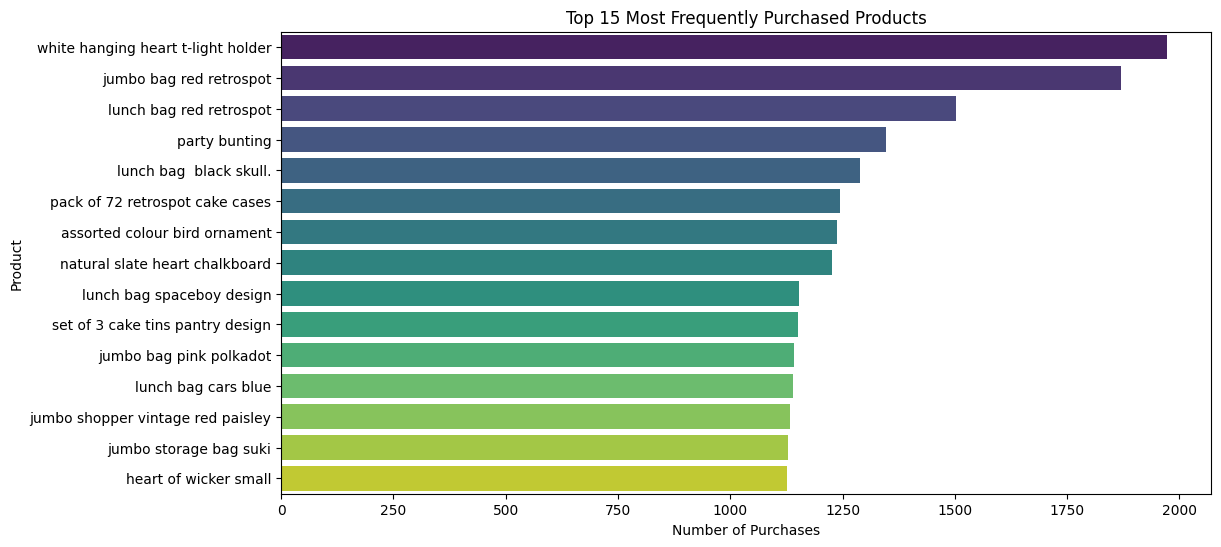

C:\Users\RayanTech\AppData\Local\Temp\ipykernel_13024\3359277287.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=country_sales.values, y=country_sales.index, palette="coolwarm")


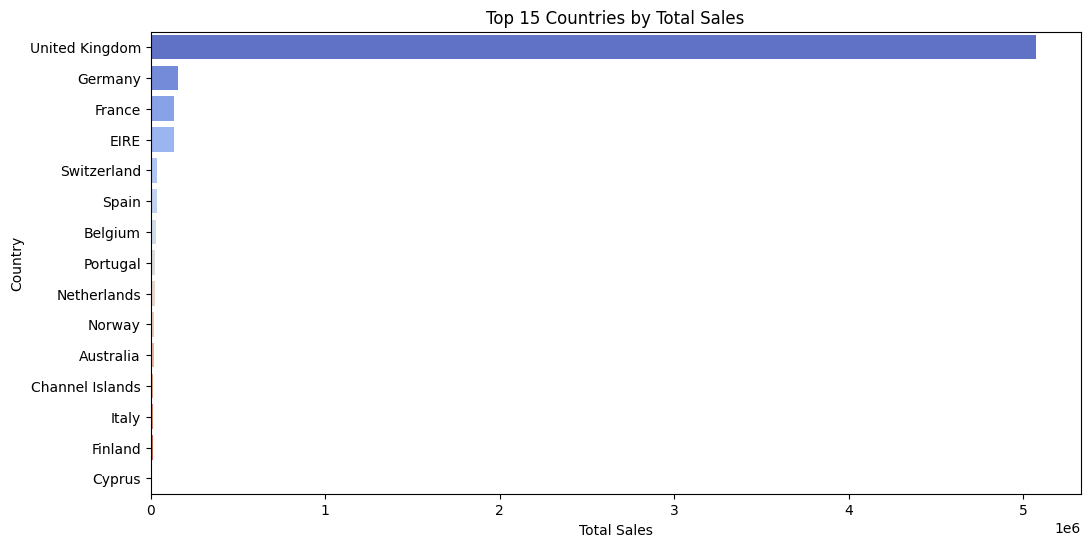

In [34]:
print(df.describe(), df.columns)

price_95 = df["UnitPrice"].quantile(0.95)
quantity_95 = df["Quantity"].quantile(0.95)
df = df[(df["UnitPrice"] <= price_95) & (df["Quantity"] <= quantity_95)]
df_filtered = df[(df["Quantity"] > 0) & 
                 (df["UnitPrice"] > 0) & 
                 (df["UnitPrice"] <= price_95) & 
                 (df["Quantity"] <= quantity_95)]
plt.figure(figsize=(8, 4))
plt.hist(df_filtered["UnitPrice"], bins=50, alpha=0.5, color='red')
plt.xlabel("UnitPrice")
plt.ylabel("Frequency (log scale)")
plt.title("Distribution of UnitPrice (positive values, log scale)")
plt.grid(alpha=0.3)
plt.show()

plt.figure(figsize=(8, 4))
plt.hist(df_filtered["Quantity"], bins=50, alpha=0.5, color='blue')
plt.xlabel("Quantity")
plt.ylabel("Frequency (log scale)")
plt.title("Distribution of Quantity (positive values, log scale)")
plt.grid(alpha=0.3)
plt.show()

top_products = df["Description"].value_counts().head(15)
print(top_products)

plt.figure(figsize=(12,6))
sns.barplot(x=top_products.values, y=top_products.index, palette="viridis")
plt.title("Top 15 Most Frequently Purchased Products")
plt.xlabel("Number of Purchases")
plt.ylabel("Product")
plt.show()

df["TotalAmount"] = df["Quantity"] * df["UnitPrice"]
country_sales = df.groupby("Country")["TotalAmount"].sum().sort_values(ascending=False).head(15)
plt.figure(figsize=(12,6))
sns.barplot(x=country_sales.values, y=country_sales.index, palette="coolwarm")
plt.title("Top 15 Countries by Total Sales")
plt.xlabel("Total Sales")
plt.ylabel("Country")
plt.show()

EDA for Association Rules 

       InvoiceNo                                        Description
0         536365  [white hanging heart t-light holder, white met...
1         536366  [hand warmer union jack, hand warmer red polka...
2         536367  [assorted colour bird ornament, poppy's playho...
3         536368  [jam making set with jars, red coat rack paris...
4         536369                         [bath building block word]
...          ...                                                ...
19731     581583  [lunch bag red retrospot, 6 chocolate love hea...
19732     581584  [red flock love heart photo frame, 6 chocolate...
19733     581585  [black tea towel classic design, assorted bott...
19734     581586  [large cake stand  hanging strawbery, set of 3...
19735     581587  [circus parade lunch box, plasters in tin circ...

[19736 rows x 2 columns]
   InvoiceNo                                        Description  NumProducts
0     536365  [white hanging heart t-light holder, white met...            7
1   

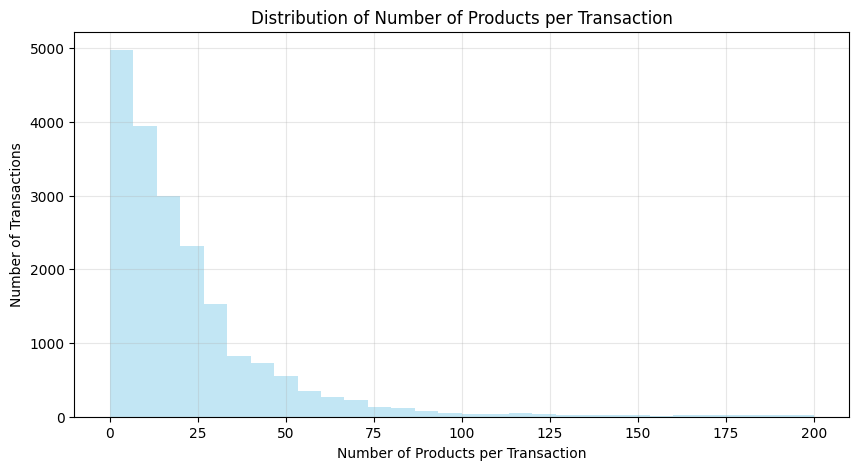

Mean products per transaction: 26.013275233076612
Median products per transaction: 15.0
Max products per transaction: 1086


In [35]:
print(baskets)
baskets["NumProducts"] = baskets["Description"].apply(len)
print(baskets.head())

plt.figure(figsize=(10,5))
plt.hist(baskets["NumProducts"], bins=30, range=(0, 200), color="skyblue", alpha=0.5)
plt.xlabel("Number of Products per Transaction")
plt.ylabel("Number of Transactions")
plt.title("Distribution of Number of Products per Transaction")
plt.grid(alpha=0.3)
plt.show()

print("Mean products per transaction:", baskets["NumProducts"].mean())
print("Median products per transaction:", baskets["NumProducts"].median())
print("Max products per transaction:", baskets["NumProducts"].max())

       InvoiceNo                                        Description  \
0         536365  [white hanging heart t-light holder, white met...   
1         536366  [hand warmer union jack, hand warmer red polka...   
2         536367  [assorted colour bird ornament, poppy's playho...   
3         536368  [jam making set with jars, red coat rack paris...   
4         536369                         [bath building block word]   
...          ...                                                ...   
19731     581583  [lunch bag red retrospot, 6 chocolate love hea...   
19732     581584  [red flock love heart photo frame, 6 chocolate...   
19733     581585  [black tea towel classic design, assorted bott...   
19734     581586  [large cake stand  hanging strawbery, set of 3...   
19735     581587  [circus parade lunch box, plasters in tin circ...   

       NumProducts  
0                7  
1                2  
2               11  
3                4  
4                1  
...            ...  


C:\Users\RayanTech\AppData\Local\Temp\ipykernel_13024\3291989156.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_items.values, y=top_items.index, palette="viridis")


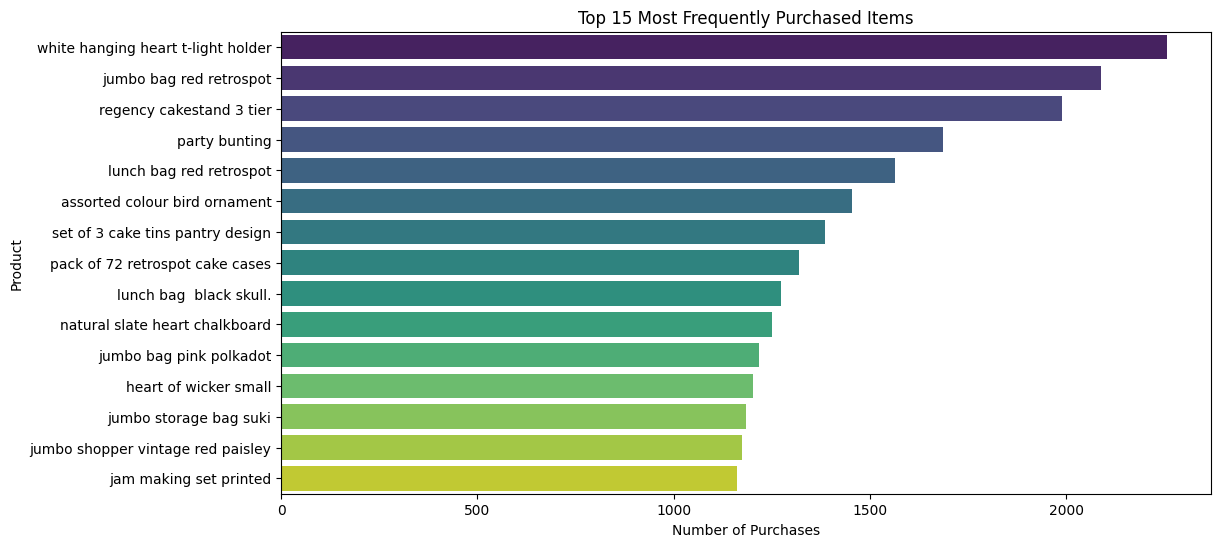

In [36]:
print(baskets)
all_items = baskets["Description"].explode()
item_counts = all_items.value_counts()
top_items = item_counts.head(15)
top_products = df["Description"].value_counts().head(15)

all_items = baskets["Description"].explode()
item_counts = all_items.value_counts() 
top_items = item_counts.head(15)

plt.figure(figsize=(12,6))
sns.barplot(x=top_items.values, y=top_items.index, palette="viridis")
plt.title("Top 15 Most Frequently Purchased Items")
plt.xlabel("Number of Purchases")
plt.ylabel("Product")
plt.show()


EDA for Time Series

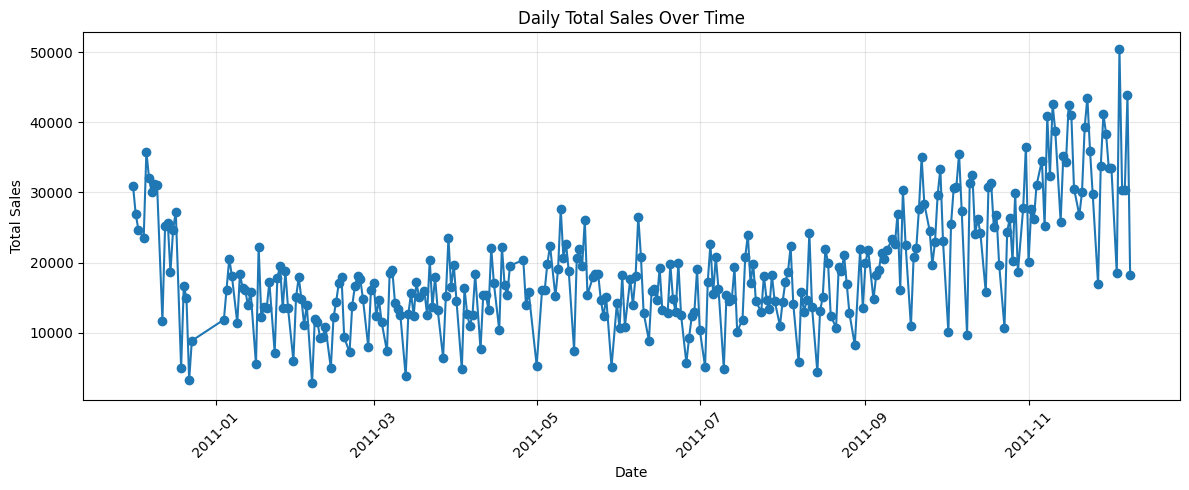

In [107]:
plt.figure(figsize=(12,5))
plt.plot(daily_sales["Date"], daily_sales["TotalAmount"], marker='o', linestyle='-')
plt.xlabel("Date")
plt.ylabel("Total Sales")
plt.title("Daily Total Sales Over Time")
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

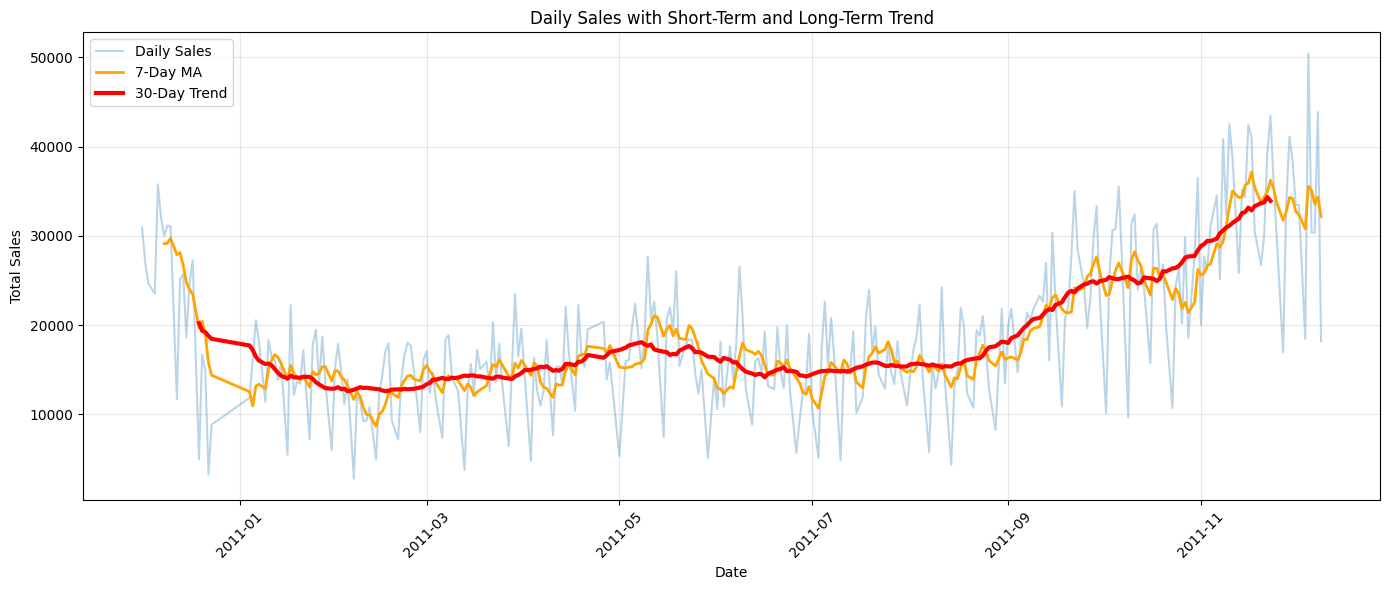

In [ ]:
daily_sales["RollingMean_7"] = daily_sales["TotalAmount"].rolling(window=7).mean()

daily_sales["Trend_30"] = daily_sales["TotalAmount"].rolling(window=30, center=True).mean()
plt.figure(figsize=(14,6))
plt.plot(daily_sales["Date"], daily_sales["TotalAmount"], alpha=0.3, label="Daily Sales")
plt.plot(daily_sales["Date"], daily_sales["RollingMean_7"], color='orange', linewidth=2, label="7-Day MA")
plt.plot(daily_sales["Date"], daily_sales["Trend_30"], color='red', linewidth=3, label="30-Day Trend")
plt.xlabel("Date")
plt.ylabel("Total Sales")
plt.title("Daily Sales with Short-Term and Long-Term Trend")
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


Association Rule Mining  

In [37]:
transactions = baskets["Description"].apply(
    lambda basket: [str(item) for item in basket]
).tolist()
te = TransactionEncoder()

te_array = te.fit(transactions).transform(transactions)
df_hot = pd.DataFrame(te_array, columns=te.columns_)
df_hot

,10 colour spaceboy pen,12 coloured party balloons,12 daisy pegs in wood box,12 egg house painted wood,12 ivory rose peg place settings,12 message cards with envelopes,12 pencil small tube woodland,12 pencils small tube red retrospot,12 pencils small tube skull,12 pencils tall tube posy,...,zinc herb garden container,zinc metal heart decoration,zinc sweetheart soap dish,zinc sweetheart wire letter rack,zinc t-light holder star large,zinc t-light holder stars small,zinc top 2 door wooden shelf,zinc willie winkie candle stick,zinc wire kitchen organiser,zinc wire sweetheart letter tray
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19731,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
19732,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
19733,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,True,False,False,True,False,False
19734,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [58]:
frequent_itemsets = apriori(df_hot, min_support=0.015, use_colnames=True)
rules = association_rules(frequent_itemsets, metric="support", min_threshold=0)
print(len(rules))

608


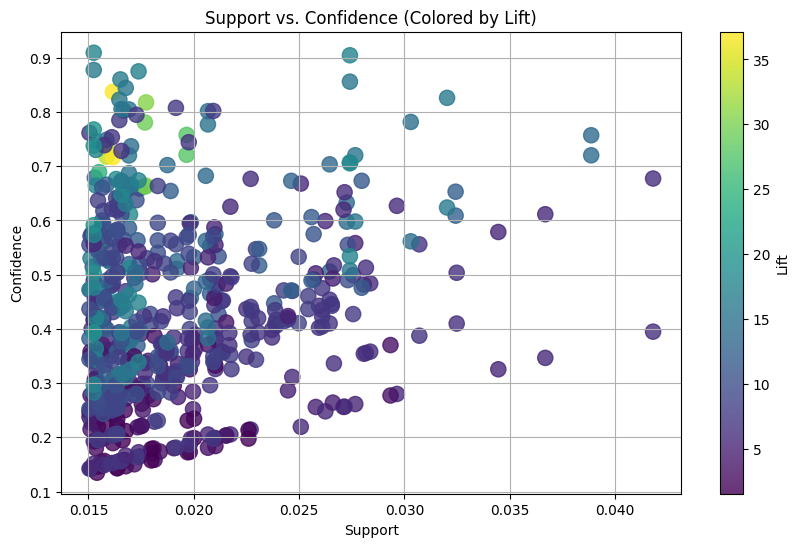

In [59]:
plt.figure(figsize=(10,6))

scatter = plt.scatter(
    rules["support"],
    rules["confidence"],
    c=rules["lift"],
    s=120,                
    alpha=0.8,            
)

plt.colorbar(scatter, label="Lift")
plt.xlabel("Support")
plt.ylabel("Confidence")
plt.title("Support vs. Confidence (Colored by Lift)")
plt.grid(True)

plt.show()

In [60]:
frequent_items = frequent_itemsets.sort_values("support", ascending=False)
frequent_items

,support,itemsets
453,0.114309,(white hanging heart t-light holder)
181,0.105847,(jumbo bag red retrospot)
322,0.100730,(regency cakestand 3 tier)
259,0.085377,(party bunting)
214,0.079246,(lunch bag red retrospot)
...,...,...
517,0.015049,"(natural slate heart chalkboard, heart of wick..."
519,0.015049,"(love building block word, home building block..."
359,0.015049,(set 6 paper table lantern hearts)
369,0.015049,(set of 3 cake tins sketchbook)


In [75]:
rules = association_rules(frequent_items, metric="support", min_threshold=0.03)
rules = rules.sort_values("support", ascending=False)
rules["support"]
len(rules)

18

support:
0.1  --> 0 rows
0.09 --> 0 rows
0.08 --> 0 rows
0.07 --> 0 rows
0.06 --> 0 rows
0.05 --> 0 rows
0.04 --> 2 rows
0.03 --> 18 rows*
0.02 --> 180 rows
0.01 --> 608 rows
I decided to keep the support of 0.03 because it was the largest support in which there were rules with lifts larger than 1; I tried with larger supports, however, non of them had a lift larger than 1 meaning they were frequent but not strong like they were purchased a lot together but more separatly.
0.06, 0.05 --> no lift larger than 1
0.04 --> 2 ones with lift larger than 1

In [76]:
rules = association_rules(frequent_items, metric="lift", min_threshold=15)
rules = rules.sort_values("lift", ascending=False)
rules["lift"]
len(rules)

90

lift:
20 --> 12
15 --> 90
10 --> 194
2 --> 598*

In [83]:
rules = association_rules(frequent_items, metric="confidence", min_threshold=0.8)
rules = rules.sort_values("confidence", ascending=False)
rules["confidence"]
len(rules)

17

confidence:
0.5 187*
0.6 98
0.7 46
0.8 17
0.9 2
considering that the lift and support thresholds are already picked, I chose the largest confidence that provided me with at least 10 rules. Therefore I will have 10 strongest rules.

In [84]:
rules.head()

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
15,"(regency cakestand 3 tier, pink regency teacup...",(green regency teacup and saucer),0.016771,0.051328,0.015251,0.909366,17.716919,1.0,0.014390,10.467020,0.959651,0.288591,0.904462,0.603251
1,"(pink regency teacup and saucer, roses regency...",(green regency teacup and saucer),0.030300,0.051328,0.027412,0.904682,17.625676,1.0,0.025857,9.952739,0.972739,0.505607,0.899525,0.719370
16,"(regency cakestand 3 tier, pink regency teacup...",(roses regency teacup and saucer),0.017379,0.053962,0.015251,0.877551,16.262298,1.0,0.014313,7.725975,0.955107,0.271906,0.870566,0.580090
7,"(regency cakestand 3 tier, pink regency teacup...",(green regency teacup and saucer),0.019862,0.051328,0.017379,0.875000,17.047384,1.0,0.016360,7.589380,0.960416,0.322976,0.868237,0.606799
12,"(charlotte bag pink polkadot, strawberry charl...",(red retrospot charlotte bag),0.019203,0.052290,0.016518,0.860158,16.449694,1.0,0.015514,6.777019,0.957598,0.300461,0.852442,0.588025


In [101]:
filtered_rules = rules[
    (rules["lift"] > 15) &
    (rules["support"] > 0.015) &
    (rules["confidence"] >= 0.8)
]

filtered_rules = filtered_rules.sort_values("lift", ascending=False)
print(len(filtered_rules))
top10_rules = filtered_rules.head(10)
top10_rules

14


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
14,(regency tea plate green),(regency tea plate roses),0.019305,0.022548,0.016163,0.837270,37.133410,1.0,0.015728,6.006602,0.992225,0.629191,0.833517,0.777062
6,(set/6 red spotty paper cups),(set/6 red spotty paper plates),0.021686,0.026702,0.017734,0.817757,30.624767,1.0,0.017155,5.340658,0.988790,0.578512,0.812757,0.740947
15,"(regency cakestand 3 tier, pink regency teacup...",(green regency teacup and saucer),0.016771,0.051328,0.015251,0.909366,17.716919,1.0,0.014390,10.467020,0.959651,0.288591,0.904462,0.603251
1,"(pink regency teacup and saucer, roses regency...",(green regency teacup and saucer),0.030300,0.051328,0.027412,0.904682,17.625676,1.0,0.025857,9.952739,0.972739,0.505607,0.899525,0.719370
7,"(regency cakestand 3 tier, pink regency teacup...",(green regency teacup and saucer),0.019862,0.051328,0.017379,0.875000,17.047384,1.0,0.016360,7.589380,0.960416,0.322976,0.868237,0.606799
12,"(charlotte bag pink polkadot, strawberry charl...",(red retrospot charlotte bag),0.019203,0.052290,0.016518,0.860158,16.449694,1.0,0.015514,6.777019,0.957598,0.300461,0.852442,0.588025
16,"(regency cakestand 3 tier, pink regency teacup...",(roses regency teacup and saucer),0.017379,0.053962,0.015251,0.877551,16.262298,1.0,0.014313,7.725975,0.955107,0.271906,0.870566,0.580090
0,(pink regency teacup and saucer),(green regency teacup and saucer),0.038762,0.051328,0.032023,0.826144,16.095532,1.0,0.030033,5.456650,0.975690,0.551483,0.816737,0.725017
2,"(pink regency teacup and saucer, green regency...",(roses regency teacup and saucer),0.032023,0.053962,0.027412,0.856013,15.863160,1.0,0.025684,6.570284,0.967957,0.467993,0.847800,0.681997
13,"(charlotte bag pink polkadot, woodland charlot...",(red retrospot charlotte bag),0.020014,0.052290,0.016467,0.822785,15.734962,1.0,0.015421,5.347791,0.955572,0.294918,0.813007,0.568854


In [102]:
top10_rules[[
    "antecedents", 
    "consequents", 
    "support", 
    "confidence", 
    "lift"
]]

,antecedents,consequents,support,confidence,lift
14,(regency tea plate green),(regency tea plate roses),0.016163,0.837270,37.133410
6,(set/6 red spotty paper cups),(set/6 red spotty paper plates),0.017734,0.817757,30.624767
15,"(regency cakestand 3 tier, pink regency teacup...",(green regency teacup and saucer),0.015251,0.909366,17.716919
1,"(pink regency teacup and saucer, roses regency...",(green regency teacup and saucer),0.027412,0.904682,17.625676
7,"(regency cakestand 3 tier, pink regency teacup...",(green regency teacup and saucer),0.017379,0.875000,17.047384
12,"(charlotte bag pink polkadot, strawberry charl...",(red retrospot charlotte bag),0.016518,0.860158,16.449694
16,"(regency cakestand 3 tier, pink regency teacup...",(roses regency teacup and saucer),0.015251,0.877551,16.262298
0,(pink regency teacup and saucer),(green regency teacup and saucer),0.032023,0.826144,16.095532
2,"(pink regency teacup and saucer, green regency...",(roses regency teacup and saucer),0.027412,0.856013,15.863160
13,"(charlotte bag pink polkadot, woodland charlot...",(red retrospot charlotte bag),0.016467,0.822785,15.734962


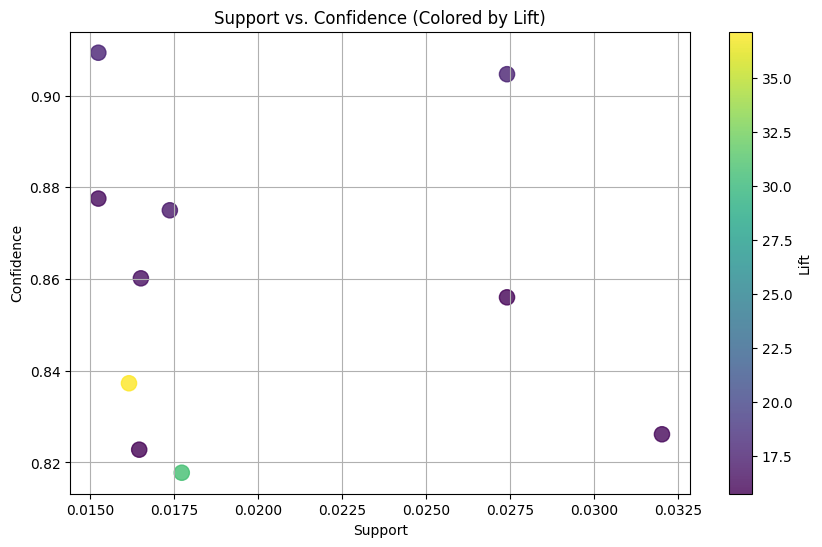

In [103]:
plt.figure(figsize=(10,6))

scatter = plt.scatter(
    top10_rules["support"],
    top10_rules["confidence"],
    c=top10_rules["lift"],
    s=120,                
    alpha=0.8,            
)

plt.colorbar(scatter, label="Lift")
plt.xlabel("Support")
plt.ylabel("Confidence")
plt.title("Support vs. Confidence (Colored by Lift)")
plt.grid(True)

plt.show()

The biggest business value is brought by the most interesting rules meaning the ones with highest lift
After filtering the lift, the confidence is prioritized meaning how likeble it is for the item Y to be purchased if item X is purchased
And after that the support is prioritized meaning how big the opportunity is 
so I chose this formula to assign some weight to each of the factors in the right order:
top10_rules["biz_score"] = (
    top10_rules["lift"] * 0.5 +
    top10_rules["confidence"] * 0.3 +
    top10_rules["support"] * 0.2
)

C:\Users\RayanTech\AppData\Local\Temp\ipykernel_13024\4282307443.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  top10_rules["biz_score"] = (


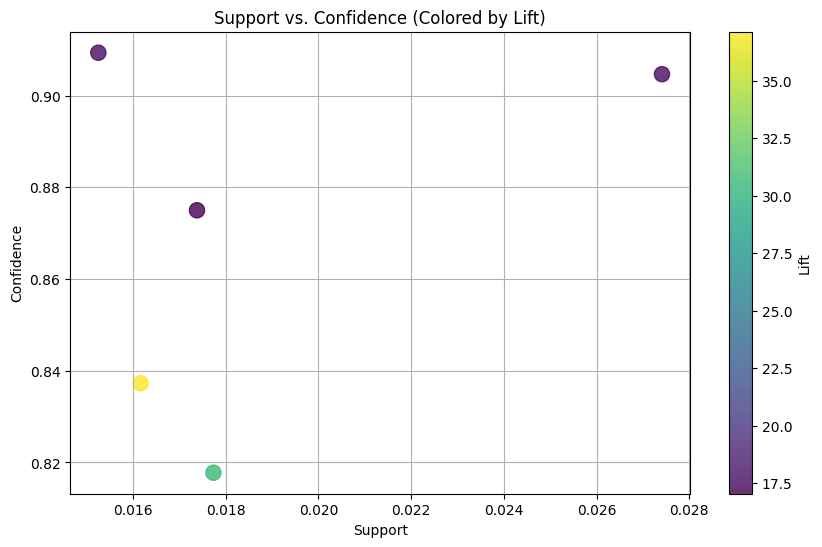

                                          antecedents  \
14                          (regency tea plate green)   
6                       (set/6 red spotty paper cups)   
15  (regency cakestand 3 tier, pink regency teacup...   
1   (pink regency teacup and saucer, roses regency...   
7   (regency cakestand 3 tier, pink regency teacup...   

                          consequents   support  confidence       lift  
14          (regency tea plate roses)  0.016163    0.837270  37.133410  
6     (set/6 red spotty paper plates)  0.017734    0.817757  30.624767  
15  (green regency teacup and saucer)  0.015251    0.909366  17.716919  
1   (green regency teacup and saucer)  0.027412    0.904682  17.625676  
7   (green regency teacup and saucer)  0.017379    0.875000  17.047384  


In [105]:
top10_rules["biz_score"] = (
    top10_rules["lift"] * 0.5 +
    top10_rules["confidence"] * 0.3 +
    top10_rules["support"] * 0.2
)

best5 = top10_rules.sort_values("biz_score", ascending=False).head(5)

plt.figure(figsize=(10,6))

scatter = plt.scatter(
    best5["support"],
    best5["confidence"],
    c=best5["lift"],
    s=120,                
    alpha=0.8,            
)

plt.colorbar(scatter, label="Lift")
plt.xlabel("Support")
plt.ylabel("Confidence")
plt.title("Support vs. Confidence (Colored by Lift)")
plt.grid(True)

plt.show()

print(
    best5[[
    "antecedents", 
    "consequents", 
    "support", 
    "confidence", 
    "lift"
]]
)

1. Bundle Promotions (Cross-sell bundles)

Rules with high confidence + high lift identify products that customers consistently buy together.

How to use the rules:

Create special bundles (e.g., “Buy X, get Y at 20% off”).

Offer automated recommendations on checkout pages (“Customers who bought X also bought Y”).

Use email campaigns: “You purchased X — here’s a discount on Y.”

Business impact:

Increases average order value (AOV).

Improves conversion rate through targeted suggestions.

2. Store/Product Placement

Rules with good support + high lift show which items should be located close to each other.

How to use the rules:

Place items that frequently co-occur in the same aisle or shelf.

In e-commerce, place them in “Recommended for you” or “Frequently bought together” sections.

Use them to optimize warehouse picking routes to reduce picking time.

Business impact:

Reduces shopping friction.

Increases impulse purchases.

Improves online recommendation accuracy.

3. Targeted Marketing Campaigns

Rules with high lift but lower support reveal small-but-valuable niche customer patterns.

How to use the rules:

Segment customers based on their previous purchases.

Send personalized offers:
“Since you bought X, here’s 10% off Y — customers like you often buy both.”

Optimize remarketing ads for products that frequently co-occur.

Business impact:

Raises ROI of ads and email campaigns.

Improves customer retention through personalization.

Part 2: Time Series Forecasting 

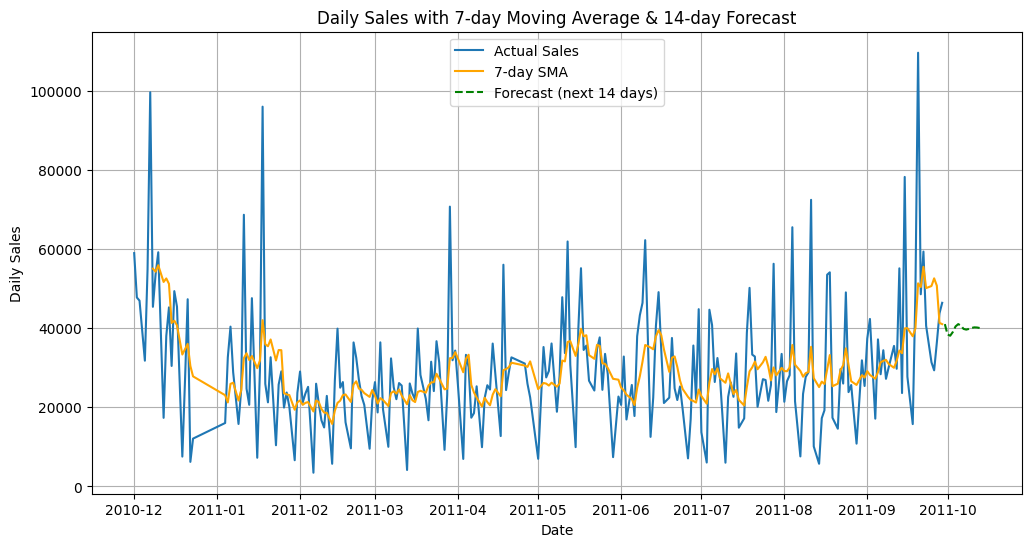

In [ ]:
daily_sales["Date"] = pd.to_datetime(daily_sales["Date"])
ts = daily_sales.set_index("Date")["TotalAmount"]

split_idx = int(len(ts) * 0.8)
train = ts.iloc[:split_idx]
test  = ts.iloc[split_idx:]

window_size = 7
forecast_days = 14

ts_sma = train.rolling(window=window_size).mean()

last_window = train[-window_size:].tolist()
forecast_values = []

for i in range(forecast_days):
    next_val = sum(last_window[-window_size:]) / window_size
    forecast_values.append(next_val)
    last_window.append(next_val)

last_date = train.index[-1]
forecast_dates = pd.date_range(start=last_date + pd.Timedelta(days=1), periods=forecast_days)

plt.figure(figsize=(12,6))
plt.plot(train, label="Actual Sales")
plt.plot(ts_sma, label=f"{window_size}-day SMA", color="orange")
plt.plot(forecast_dates, forecast_values, label="Forecast (next 14 days)", linestyle='--', color='green')
plt.xlabel("Date")
plt.ylabel("Daily Sales")
plt.title("Daily Sales with 7-day Moving Average & 14-day Forecast")
plt.legend()
plt.grid(True)
plt.show()


There are 2 cases of prediction generations using SMA method; at each timestamp there are 2 possibilities: adding the predicted value to the window or replacing the actual value.
The point is that MA is a smoothing method and after 2 iterations of window size it completely flattens. However, replacing the actual values avoids that kind of flattening and improves accuracy a little bit. Below comes both cases and as can be seen in the case of no replacement, the method made more realistic predictions.

MAE : 20728.92838000317
RMSE: 30642.23641548911
MAPE: 41.20700256043545


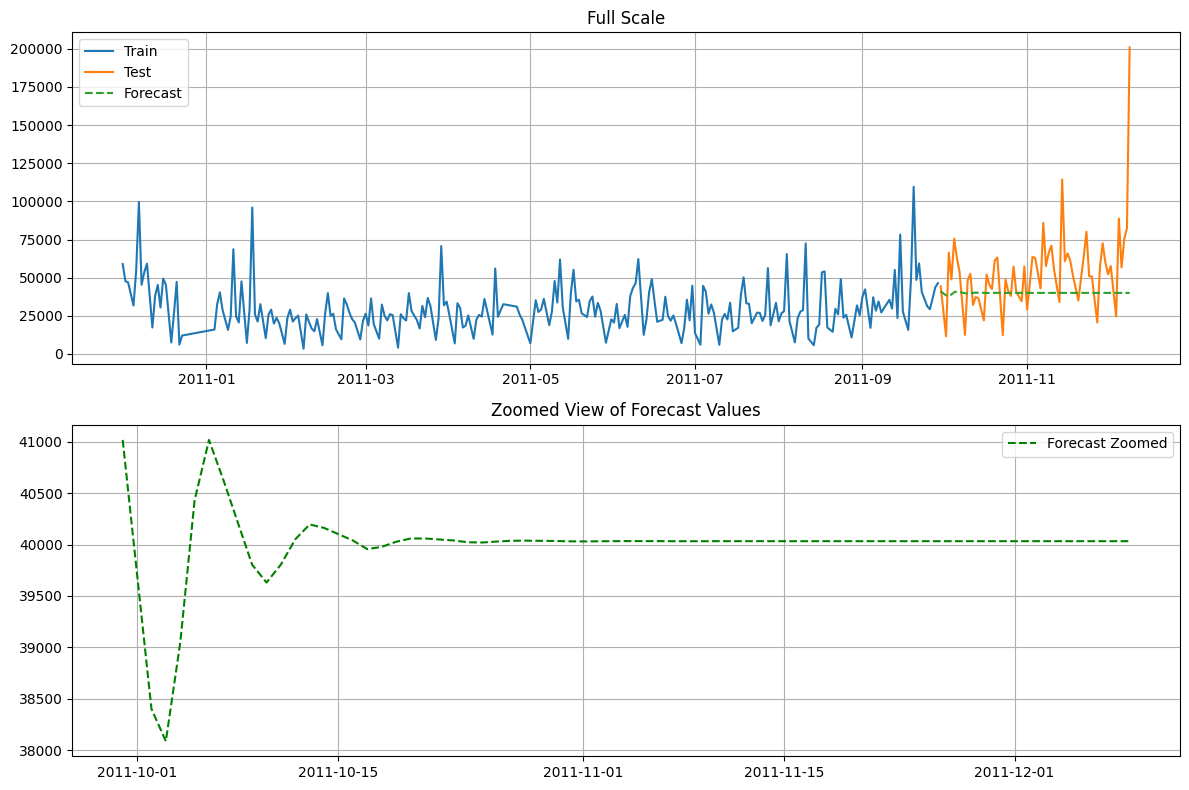

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

daily_sales["Date"] = pd.to_datetime(daily_sales["Date"])
ts = daily_sales.set_index("Date")["TotalAmount"].sort_index()

split_idx = int(len(ts) * 0.8)
train = ts.iloc[:split_idx]
test  = ts.iloc[split_idx:]

window_size = 7
forecast_days = len(test)
last_window = list(train.iloc[-window_size:])

forecast_values = []

for i in range(forecast_days):
    next_val = sum(last_window[-window_size:]) / window_size
    forecast_values.append(next_val)
    last_window.append(next_val)

forecast = pd.Series(forecast_values, index=test.index)

mae = mean_absolute_error(test, forecast)
mse = mean_squared_error(test, forecast)
rmse = np.sqrt(mse)
mape = np.mean(np.abs((test - forecast) / test)) * 100

print("MAE :", mae)
print("RMSE:", rmse)
print("MAPE:", mape)

plt.figure(figsize=(12,8))

plt.subplot(2,1,1)
plt.plot(train, label="Train")
plt.plot(test, label="Test")
plt.plot(forecast, label="Forecast", linestyle='--')
plt.title("Full Scale")
plt.legend()
plt.grid(True)

plt.subplot(2,1,2)
plt.plot(forecast, label="Forecast Zoomed", linestyle='--', color='green')
plt.title("Zoomed View of Forecast Values")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()


MAE : 16806.798540983607
RMSE: 25976.773745631264
MAPE: 40.85032401094074


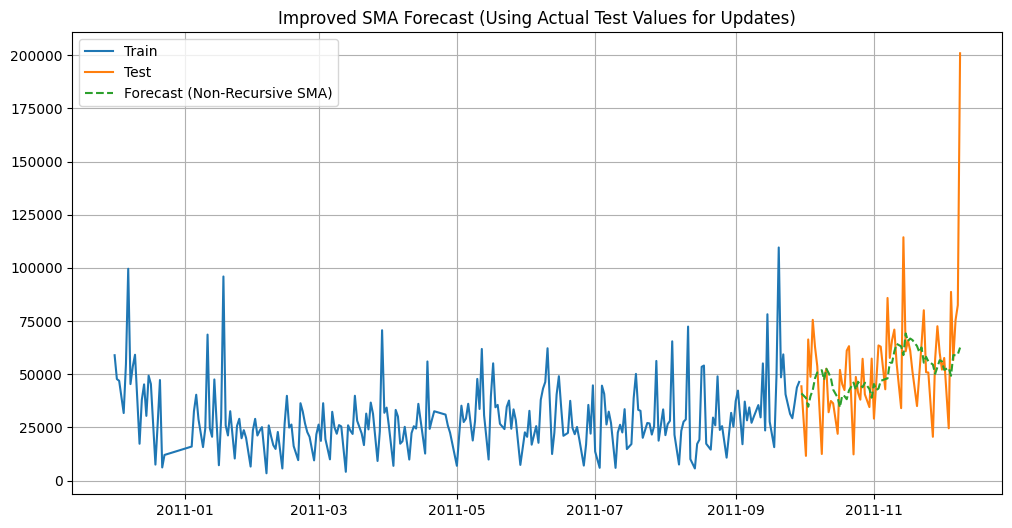

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error

daily_sales["Date"] = pd.to_datetime(daily_sales["Date"])
ts = daily_sales.set_index("Date")["TotalAmount"].sort_index()

split_idx = int(len(ts) * 0.8)
train = ts.iloc[:split_idx]
test = ts.iloc[split_idx:]

window_size = 7

rolling_window = list(train.iloc[-window_size:])

forecast_values = []

for actual in test:
    forecast = sum(rolling_window[-window_size:]) / window_size
    forecast_values.append(forecast)
    rolling_window.append(actual)

forecast = pd.Series(forecast_values, index=test.index)

mae = mean_absolute_error(test, forecast)
mse = mean_squared_error(test, forecast)
rmse = np.sqrt(mse)
mape = np.mean(np.abs((test - forecast) / test)) * 100

print("MAE :", mae)
print("RMSE:", rmse)
print("MAPE:", mape)

# Plot
plt.figure(figsize=(12,6))
plt.plot(train, label="Train")
plt.plot(test, label="Test")
plt.plot(forecast, label="Forecast (Non-Recursive SMA)", linestyle='--')
plt.title("Improved SMA Forecast (Using Actual Test Values for Updates)")
plt.legend()
plt.grid(True)
plt.show()


Analysis and Interpretation  
SMA is one of the least reliable forecasting methods for anything beyond very short-term prediction and the flattening we observed is exactly why.
Reason 1: SMA cannot model trend

If data is trending upward or downward:
SMA smooths it out, forecast stays “in the middle” and completely misses the trend

Reason 2: SMA cannot model seasonality
If sales have weekly patterns (Mon–Sun cycle), SMA ignores this.

Reason 3: Recursive SMA always collapses to a constant
Recursive forecasting means:
Predict tomorrow using today's forecast, Predict next day using today's predicted value

Evaluation Metrics:
MAE = (1/n) Σ(i=1 to n) |y_i – ŷ_i|
mean squared error (MSE), the average squared difference between the value observed in a statistical study and the values predicted from a model.
It provides an estimate of the size of the inaccuracy, but not its direction (e.g., over or under-prediction).
Resiliency to outliers. The MAE is not as impacted by extreme results as other metrics, such as Mean Squared Error (MSE), are. This makes it an appropriate measure for datasets that include outliers or extreme values.

RMSE = sqrt [(Σ(Pi – Oi)²) / n]
It is one of the standard ways to measure the error rate of a model in predicting quantitative data.
It is a metric predominantly utilized in regression analysis and forecasting, where accuracy matters significantly. The lower the RMSE, the better the model’s ability to predict accurately. Conversely, a higher RMSE signifies a greater discrepancy between the predicted and actual outcomes.

MAPE
Mean absolute percentage error measures the average magnitude of error produced by a model, or how far off predictions are on average. A MAPE value of 20% means that the average absolute percentage difference between the predictions and the actuals is 20%
MAPE=n1​∑ (​∣Actual_i​ − Forecast_i​∣ / ​Actual_i ) ​×100